In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scanpy as sc

# ---------------------- CUSTOM PARAMETERS ----------------------
DATASET = "lungatlas"
INPUT_PATH = f"data/{DATASET}/adata_with_embedding.h5ad"
SAVE_PATH = f"images/xxx_{DATASET}.png"

# Plot parameters
CLUSTERMAP_FIGSIZE = (10, 12)
CMAP_NAME = "rocket"
COLOR_PALETTE = "Set2"
DPI_VALUE = 300

# Colorbar position [left, bottom, width, height]
CB_POSITION = [0.02, 0.35, 0.02, 0.3]

In [2]:
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)

In [3]:
adata = sc.read_h5ad(INPUT_PATH)
emb = np.asarray(adata.obsm["X_emb"])
cell_type = np.array(adata.obs["cell_type"].values)

In [4]:
order = np.argsort(cell_type)
emb_sorted = emb[order]
cell_type_sorted = cell_type[order]

In [5]:
unique_types = np.unique(cell_type_sorted)
palette = sns.color_palette(COLOR_PALETTE, len(unique_types))
color_map = dict(zip(unique_types, palette))
row_colors = np.array([color_map[x] for x in cell_type_sorted])

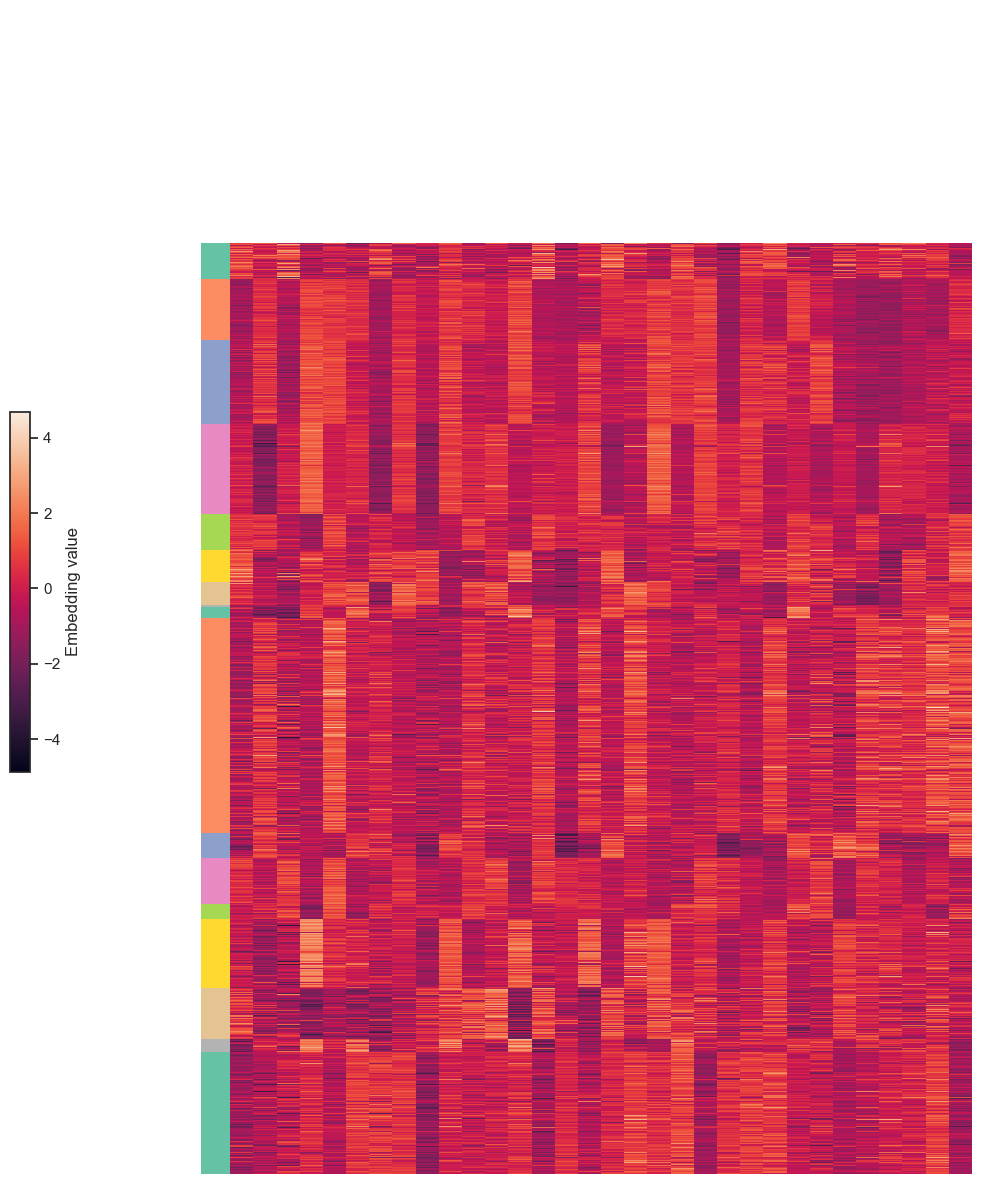

In [6]:
sns.set(style="white")

g = sns.clustermap(
    emb_sorted,
    row_cluster=False,
    col_cluster=False,
    row_colors=row_colors,
    cmap=CMAP_NAME,
    figsize=CLUSTERMAP_FIGSIZE,
    xticklabels=False,
    yticklabels=False,
    cbar_pos=None
)
mappable = g.ax_heatmap.collections[0]
cax = g.fig.add_axes(CB_POSITION)
cb = plt.colorbar(mappable, cax=cax)
cb.set_label("Embedding value", rotation=90)
g.ax_row_dendrogram.set_visible(False)

plt.savefig(SAVE_PATH, dpi=DPI_VALUE, bbox_inches="tight")
plt.show()
plt.close()

In [7]:
print(f"Saved to: {SAVE_PATH}")

Saved to: images/xxx_lungatlas.png
